In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportion_confint

np.random.seed(42)

sns.set_theme(style="whitegrid")

In [7]:
from pathlib import Path

DATA_DIR = Path("../data")
CSV_FILE = DATA_DIR / "framingham.csv"

df = pd.read_csv(CSV_FILE)

df = df.dropna()

print(df.shape)
df.head()

(3658, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# Sumativa 2
## Bootstrap, Permutación y Simulación Monte Carlo

Este trabajo extiende los análisis realizados en la Sumativa 1 mediante técnicas de remuestreo y simulación.

Objetivos:
- Evaluar la estabilidad de las estimaciones obtenidas.
- Comparar intervalos clásicos con intervalos bootstrap.
- Validar resultados inferenciales mediante pruebas de permutación.
- Analizar la estabilidad de correlaciones.
- Simular escenarios poblacionales mediante Monte Carlo.

# 1. Bootstrap de parámetros poblacionales

En la Sumativa 1 se estimaron diversos parámetros poblacionales mediante intervalos de confianza basados en el Teorema del Límite Central.

En esta sección se utilizará Bootstrap para evaluar la estabilidad de dichas estimaciones y comparar los resultados con los intervalos clásicos obtenidos previamente.

Parámetros analizados:

- Edad promedio
- Colesterol total promedio
- Presión sistólica promedio
- Proporción de enfermedad coronaria a 10 años (TenYearCHD)

In [8]:
def bootstrap_ci_mean(data, variable_name, n_boot=10000):

    medias = []

    data = np.array(data)

    for _ in range(n_boot):
        muestra = np.random.choice(
            data,
            size=len(data),
            replace=True
        )

        medias.append(np.mean(muestra))

    medias = np.array(medias)

    ic_boot = np.percentile(
        medias,
        [2.5, 97.5]
    )

    media_original = np.mean(data)

    ic_clasico = stats.t.interval(
        confidence=0.95,
        df=len(data)-1,
        loc=media_original,
        scale=np.std(data, ddof=1) / np.sqrt(len(data))
    )

    print(f"\n{variable_name}")
    print("-"*50)
    print(f"Media observada : {media_original:.4f}")
    print(f"IC clásico      : [{ic_clasico[0]:.4f}, {ic_clasico[1]:.4f}]")
    print(f"IC bootstrap    : [{ic_boot[0]:.4f}, {ic_boot[1]:.4f}]")

    return {
        "media": media_original,
        "ic_clasico": ic_clasico,
        "ic_boot": ic_boot,
        "bootstrap_samples": medias
    }

In [9]:
edad_result = bootstrap_ci_mean(
    df["age"],
    "Edad"
)

colesterol_result = bootstrap_ci_mean(
    df["totChol"],
    "Colesterol total"
)

presion_result = bootstrap_ci_mean(
    df["sysBP"],
    "Presión sistólica"
)


Edad
--------------------------------------------------
Media observada : 49.5519
IC clásico      : [49.2744, 49.8295]
IC bootstrap    : [49.2747, 49.8338]

Colesterol total
--------------------------------------------------
Media observada : 236.8477
IC clásico      : [235.4182, 238.2772]
IC bootstrap    : [235.4038, 238.2942]

Presión sistólica
--------------------------------------------------
Media observada : 132.3706
IC clásico      : [131.6546, 133.0865]
IC bootstrap    : [131.6390, 133.0947]


In [10]:
tabla_bootstrap = pd.DataFrame({
    "Variable": [
        "Edad",
        "Colesterol total",
        "Presión sistólica"
    ],

    "Media": [
        edad_result["media"],
        colesterol_result["media"],
        presion_result["media"]
    ],

    "IC clásico inferior": [
        edad_result["ic_clasico"][0],
        colesterol_result["ic_clasico"][0],
        presion_result["ic_clasico"][0]
    ],

    "IC clásico superior": [
        edad_result["ic_clasico"][1],
        colesterol_result["ic_clasico"][1],
        presion_result["ic_clasico"][1]
    ],

    "IC bootstrap inferior": [
        edad_result["ic_boot"][0],
        colesterol_result["ic_boot"][0],
        presion_result["ic_boot"][0]
    ],

    "IC bootstrap superior": [
        edad_result["ic_boot"][1],
        colesterol_result["ic_boot"][1],
        presion_result["ic_boot"][1]
    ]
})

tabla_bootstrap.round(4)

,Variable,Media,IC clásico inferior,IC clásico superior,IC bootstrap inferior,IC bootstrap superior
0,Edad,49.5519,49.2744,49.8295,49.2747,49.8338
1,Colesterol total,236.8477,235.4182,238.2772,235.4038,238.2942
2,Presión sistólica,132.3706,131.6546,133.0865,131.6390,133.0947


### Interpretación

Los intervalos de confianza bootstrap obtenidos para la edad, el colesterol total y la presión sistólica son muy similares a los intervalos clásicos calculados mediante la distribución t de Student.

Esta consistencia indica que las estimaciones obtenidas en la Sumativa 1 son estables frente al remuestreo y que los parámetros calculados representan adecuadamente las características de la población analizada.

Las pequeñas diferencias observadas entre ambos métodos son esperables y se deben a la naturaleza no paramétrica del bootstrap, que estima la variabilidad directamente a partir de los datos observados.

## Bootstrap para la proporción de enfermedad coronaria

En la Sumativa 1 se estimó la proporción de pacientes que desarrollan enfermedad coronaria a diez años utilizando un intervalo de confianza de Wilson.

En esta sección se utilizará Bootstrap para estimar la distribución muestral de la proporción y comparar ambos enfoques.

In [11]:
def bootstrap_proportion(data, n_boot=10000):

    proporciones = []

    data = np.array(data)

    for _ in range(n_boot):

        muestra = np.random.choice(
            data,
            size=len(data),
            replace=True
        )

        proporciones.append(np.mean(muestra))

    return np.array(proporciones)

In [12]:
chd_boot = bootstrap_proportion(
    df["TenYearCHD"]
)

p_hat = df["TenYearCHD"].mean()

ic_boot_chd = np.percentile(
    chd_boot,
    [2.5, 97.5]
)

print(f"Proporción observada : {p_hat:.4f} ({p_hat*100:.2f}%)")

print(
    f"IC Bootstrap 95%     : "
    f"[{ic_boot_chd[0]:.4f}, {ic_boot_chd[1]:.4f}]"
)

print(
    f"                      "
    f"[{ic_boot_chd[0]*100:.2f}%, {ic_boot_chd[1]*100:.2f}%]"
)

Proporción observada : 0.1523 (15.23%)
IC Bootstrap 95%     : [0.1408, 0.1638]
                      [14.08%, 16.38%]


In [13]:
casos = int(df["TenYearCHD"].sum())
total = len(df)

ic_wilson = proportion_confint(
    casos,
    total,
    alpha=0.05,
    method="wilson"
)

comparacion_prop = pd.DataFrame({

    "Método": [
        "Wilson",
        "Bootstrap"
    ],

    "Límite inferior (%)": [
        ic_wilson[0]*100,
        ic_boot_chd[0]*100
    ],

    "Límite superior (%)": [
        ic_wilson[1]*100,
        ic_boot_chd[1]*100
    ]
})

comparacion_prop.round(2)

,Método,Límite inferior (%),Límite superior (%)
0,Wilson,14.10,16.43
1,Bootstrap,14.08,16.38


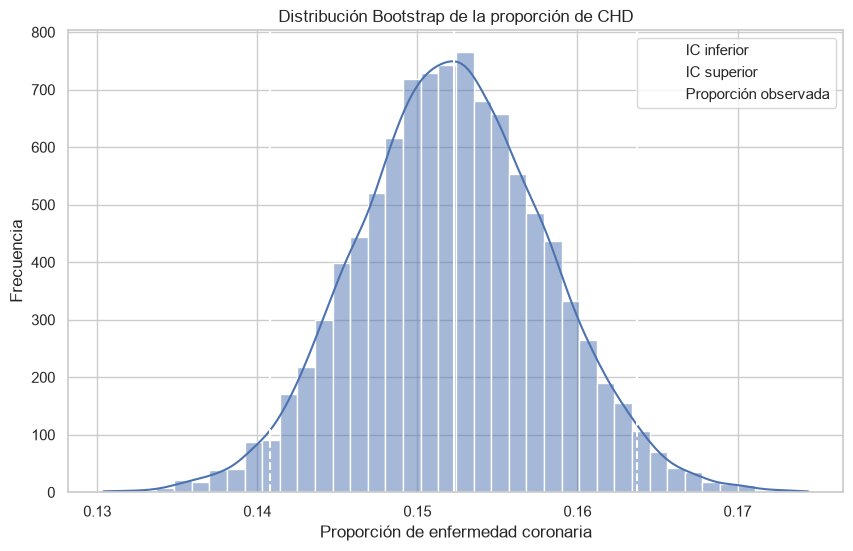

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    chd_boot,
    bins=40,
    kde=True
)

plt.axvline(
    ic_boot_chd[0],
    linestyle="--",
    label="IC inferior"
)

plt.axvline(
    ic_boot_chd[1],
    linestyle="--",
    label="IC superior"
)

plt.axvline(
    p_hat,
    linestyle="-",
    label="Proporción observada"
)

plt.title(
    "Distribución Bootstrap de la proporción de CHD"
)

plt.xlabel(
    "Proporción de enfermedad coronaria"
)

plt.ylabel("Frecuencia")

plt.legend()

plt.show()

### Interpretación

La distribución bootstrap de la proporción de enfermedad coronaria a 10 años presenta una forma aproximadamente normal y centrada en la proporción observada de la muestra (15,23%). Esto indica que la estimación es estable frente al remuestreo y que no depende de observaciones particulares del conjunto de datos.

El intervalo de confianza bootstrap al 95% fue [14,08%; 16,38%], mientras que el intervalo obtenido mediante el método de Wilson en la Sumativa 1 fue [14,10%; 16,43%]. La diferencia entre ambos enfoques es mínima, con variaciones inferiores a 0,1 puntos porcentuales en los límites del intervalo.

La alta concordancia entre ambos métodos proporciona evidencia adicional de la robustez de la estimación realizada previamente y sugiere que la proporción poblacional de individuos que desarrollan enfermedad coronaria a diez años se encuentra cercana al 15% en la población representada por la muestra.

La similitud observada entre un método paramétrico (Wilson) y uno basado en remuestreo (Bootstrap) indica que la incertidumbre asociada a esta estimación está adecuadamente caracterizada y que los resultados obtenidos en la Sumativa 1 son consistentes bajo diferentes estrategias de inferencia estadística.

# 2. Validación de hipótesis mediante permutación

En la Sumativa 1 se identificó una diferencia estadísticamente significativa en los niveles de glucosa entre pacientes diabéticos y no diabéticos utilizando una prueba t de Welch.

En esta sección se utilizará una prueba de permutación para validar dicho resultado sin asumir distribuciones paramétricas, generando una distribución nula mediante la reasignación aleatoria de las etiquetas de grupo.

In [15]:
grupo_diabeticos = df[df["diabetes"] == 1]["glucose"]
grupo_no_diabeticos = df[df["diabetes"] == 0]["glucose"]

diferencia_observada = (
    grupo_diabeticos.mean()
    - grupo_no_diabeticos.mean()
)

print(
    f"Diferencia observada: "
    f"{diferencia_observada:.2f} mg/dL"
)

Diferencia observada: 90.56 mg/dL


In [18]:
n_perm = 10000

diferencias_perm = []

glucosa = df["glucose"].values
etiquetas = df["diabetes"].values

for _ in range(n_perm):

    etiquetas_perm = np.random.permutation(
        etiquetas
    )

    media_diab = glucosa[
        etiquetas_perm == 1
    ].mean()

    media_no_diab = glucosa[
        etiquetas_perm == 0
    ].mean()

    diferencias_perm.append(
        media_diab - media_no_diab
    )

diferencias_perm = np.array(
    diferencias_perm
)

In [22]:
p_perm = np.mean(
    np.abs(diferencias_perm)
    >= abs(diferencia_observada)
)

if p_perm == 0:
    print(
        f"p-valor por permutación: < {1/n_perm:.5f}"
    )
else:
    print(
        f"p-valor por permutación: {p_perm:.6f}"
    )

p-valor por permutación: < 0.00010


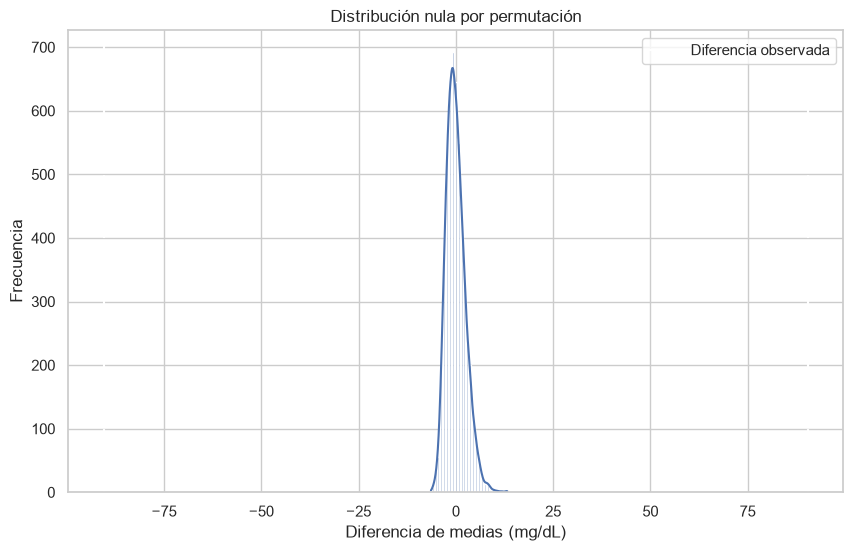

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    diferencias_perm,
    bins=50,
    kde=True
)

plt.axvline(
    diferencia_observada,
    linestyle="--",
    label="Diferencia observada"
)

plt.axvline(
    -diferencia_observada,
    linestyle="--"
)

plt.title(
    "Distribución nula por permutación"
)

plt.xlabel(
    "Diferencia de medias (mg/dL)"
)

plt.ylabel(
    "Frecuencia"
)

plt.legend()

plt.show()

In [27]:
comparacion_hipotesis = pd.DataFrame({
    "Método": ["Welch", "Permutación"],
    "Resultado": [
        "t = 10.6173",
        "Δ = 90.56 mg/dL"
    ],
    "p-valor": [
        5.48e-18,
        p_perm
    ]
})

comparacion_hipotesis

,Método,Resultado,p-valor
0,Welch,t = 10.6173,5.480000e-18
1,Permutación,Δ = 90.56 mg/dL,0.000000e+00


### Interpretación

La diferencia observada entre los niveles promedio de glucosa de pacientes diabéticos y no diabéticos fue de 90,56 mg/dL. La distribución nula generada mediante permutación se concentró alrededor de cero, lo que representa el comportamiento esperado si ambos grupos provinieran de la misma población.

Ninguna de las 10.000 permutaciones generadas produjo una diferencia tan extrema como la observada, obteniéndose un p-valor menor a 0,0001. Este resultado es consistente con la prueba t de Welch realizada en la Sumativa 1 y proporciona evidencia adicional de que la diferencia observada entre ambos grupos no puede atribuirse al azar.

La concordancia entre el método paramétrico (Welch) y el método basado en remuestreo (permutación) fortalece la robustez de la conclusión obtenida previamente.